<a href="https://colab.research.google.com/github/AiWriter404/House-Prices-EDA-Analysis/blob/main/Smart_House_Recommendation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Smart House Recommendation Analysis

## Scenario
A client wants to buy a house with a limited budget.

We will:
- Create a realistic house dataset
- Analyze house prices
- Filter houses according to the client's budget
- Recommend suitable areas
- Predict what features the client can get within the budget



In [1]:

# Import required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Show plots inside notebook
%matplotlib inline

# Set plot style
sns.set_style("whitegrid")

print("Libraries imported successfully!")


Libraries imported successfully!



## Step 1 - Create a Realistic House Dataset

We will generate a sample housing dataset using Python.


In [2]:

# Set random seed for reproducibility

np.random.seed(42)

# Create possible city areas
areas = [
    "Downtown",
    "Green Valley",
    "Sunset Town",
    "Lake View",
    "Royal City",
    "Hill Park"
]

# Create dataset
data = {
    "Area": np.random.choice(areas, 300),
    "Square_Feet": np.random.randint(700, 4500, 300),
    "Bedrooms": np.random.randint(1, 6, 300),
    "Bathrooms": np.random.randint(1, 5, 300),
    "Garage": np.random.randint(0, 3, 300),
    "Age": np.random.randint(1, 35, 300),
}

# Convert into dataframe
df = pd.DataFrame(data)

# Create realistic price column
df["Price"] = (
    df["Square_Feet"] * 130 +
    df["Bedrooms"] * 18000 +
    df["Bathrooms"] * 12000 +
    df["Garage"] * 9000 -
    df["Age"] * 1500 +
    np.random.randint(-25000, 25000, 300)
)

# Show first 5 rows
df.head()


,Area,Square_Feet,Bedrooms,Bathrooms,Garage,Age,Price
0,Lake View,3883,4,4,0,34,597691
1,Royal City,3257,2,3,0,17,479360
2,Sunset Town,2196,5,3,2,25,399176
3,Royal City,798,3,1,2,12,150366
4,Royal City,2900,2,4,1,23,417924



## Step 2 - Basic Dataset Information


In [3]:

# Dataset shape

print("Dataset Shape:", df.shape)

# Show columns
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()


Dataset Shape: (300, 7)

Columns:
Index(['Area', 'Square_Feet', 'Bedrooms', 'Bathrooms', 'Garage', 'Age',
       'Price'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Area         300 non-null    object
 1   Square_Feet  300 non-null    int64 
 2   Bedrooms     300 non-null    int64 
 3   Bathrooms    300 non-null    int64 
 4   Garage       300 non-null    int64 
 5   Age          300 non-null    int64 
 6   Price        300 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 16.5+ KB



## Step 3 - Statistical Summary


In [4]:

# Statistical summary of dataset

df.describe()


,Square_Feet,Bedrooms,Bathrooms,Garage,Age,Price
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2587.186667,3.030000,2.420000,1.033333,18.513333,402024.980000
std,1089.728452,1.472978,1.089752,0.821262,9.743353,148175.014218
min,704.000000,1.000000,1.000000,0.000000,1.000000,109151.000000
25%,1658.500000,2.000000,1.000000,0.000000,11.000000,276771.000000
50%,2504.500000,3.000000,2.000000,1.000000,18.000000,396823.500000
75%,3554.000000,4.000000,3.000000,2.000000,27.000000,520584.750000
max,4491.000000,5.000000,4.000000,2.000000,34.000000,710082.000000



## Step 4 - Client Budget Selection

Suppose the client has a maximum budget of:

# 400,000


In [5]:

# Client maximum budget

budget = 400000

print("Client Budget:", budget)


Client Budget: 400000



## Step 5 - Filter Houses Within Budget


In [6]:

# Filter houses within the client's budget

budget_houses = df[df["Price"] <= budget]

# Show number of available houses
print("Available Houses:", len(budget_houses))

# Display first rows
budget_houses.head()


Available Houses: 153


,Area,Square_Feet,Bedrooms,Bathrooms,Garage,Age,Price
2,Sunset Town,2196,5,3,2,25,399176
3,Royal City,798,3,1,2,12,150366
5,Green Valley,2584,3,2,1,22,377777
7,Sunset Town,2619,2,2,2,27,372952
8,Sunset Town,1577,5,3,2,31,288935



## Step 6 - Areas Where the Client Can Buy a House


In [7]:

# Count available houses in each area

area_counts = budget_houses["Area"].value_counts()

print(area_counts)


Area
Lake View       35
Downtown        30
Green Valley    26
Sunset Town     24
Hill Park       23
Royal City      15
Name: count, dtype: int64



## Step 7 - Visualize Affordable Areas


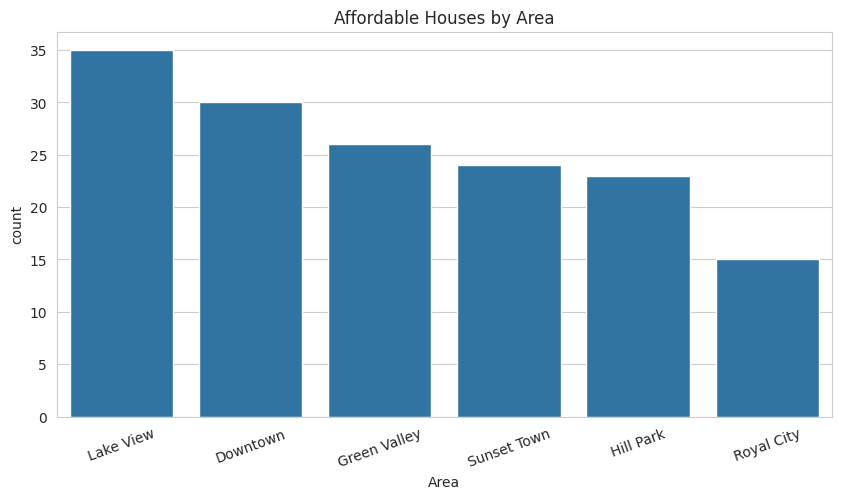

In [8]:

# Plot affordable areas

plt.figure(figsize=(10,5))

sns.countplot(
    data=budget_houses,
    x="Area",
    order=budget_houses["Area"].value_counts().index
)

plt.title("Affordable Houses by Area")
plt.xticks(rotation=20)

plt.show()



## Step 8 - What Features Can the Client Get?


In [9]:

# Average features of affordable houses

features = budget_houses[[
    "Square_Feet",
    "Bedrooms",
    "Bathrooms",
    "Garage",
    "Age",
    "Price"
]].mean()

print("Average Features of Affordable Houses:")
print(features)


Average Features of Affordable Houses:
Square_Feet      1671.836601
Bedrooms            2.836601
Bathrooms           2.294118
Garage              1.013072
Age                19.496732
Price          275380.666667
dtype: float64



## Step 9 - Relationship Between Area and Price


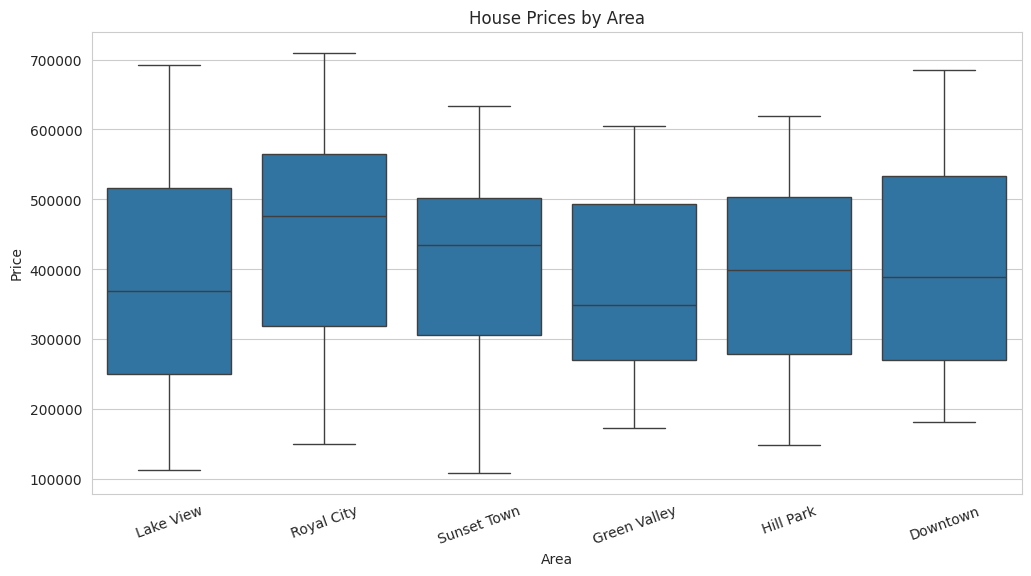

In [10]:

# Boxplot for area vs price

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Area",
    y="Price"
)

plt.title("House Prices by Area")
plt.xticks(rotation=20)

plt.show()



## Step 10 - Find Best Affordable Houses


In [11]:

# Sort affordable houses by square feet

best_houses = budget_houses.sort_values(
    by="Square_Feet",
    ascending=False
)

# Show top 10 best affordable houses
best_houses.head(10)


,Area,Square_Feet,Bedrooms,Bathrooms,Garage,Age,Price
239,Hill Park,2841,1,2,2,7,395943
45,Downtown,2774,1,2,0,30,346167
88,Royal City,2706,2,3,2,31,397704
195,Sunset Town,2674,2,1,2,5,393123
283,Sunset Town,2631,4,1,0,29,377867
204,Downtown,2631,1,2,1,33,363771
23,Green Valley,2619,1,2,0,21,365311
7,Sunset Town,2619,2,2,2,27,372952
136,Green Valley,2606,1,1,2,24,341129
5,Green Valley,2584,3,2,1,22,377777



## Step 11 - Correlation Analysis


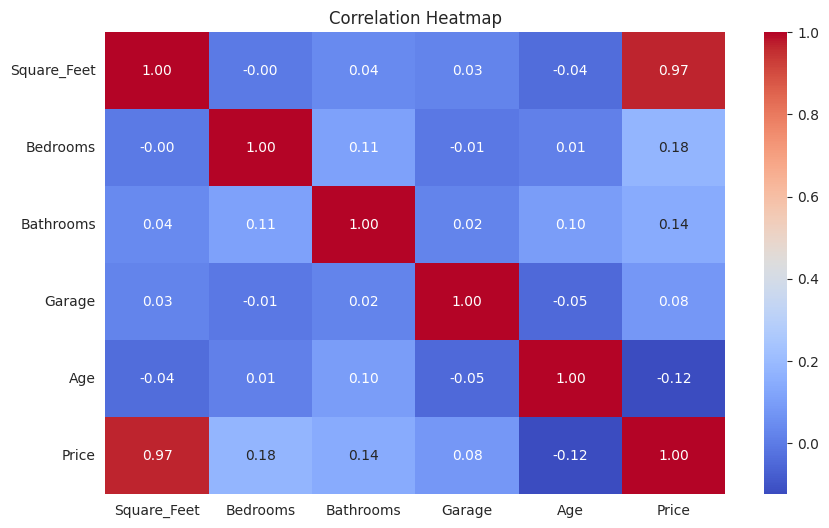

In [12]:

# Correlation matrix

correlation = df.corr(numeric_only=True)

# Plot heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()



# Final Recommendation

## Based on the analysis:

The client can most likely find affordable houses in:
- Green Valley
- Sunset Town
- Hill Park

## Expected Features:
- 2 to 4 Bedrooms
- 1 to 3 Bathrooms
- Medium to Large House Size
- Possible Garage Availability

## Important Learning:
This project demonstrates how data analysis can help clients make smart real estate decisions using Python and Seaborn.
